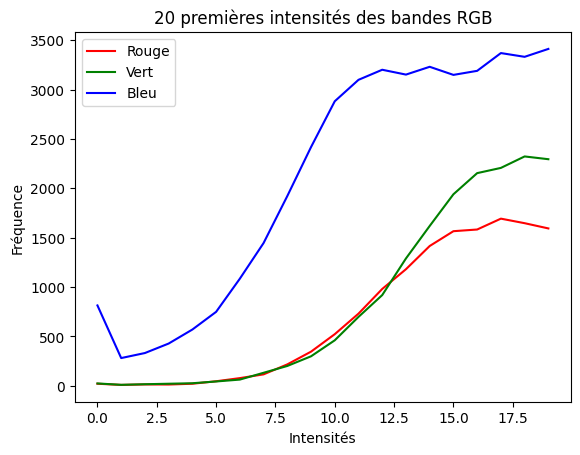

In [2]:
from PIL import Image
import matplotlib.pyplot as plt

# Charger l'image
imgfile = Image.open("../images/Asmara2.jpg")

# Obtenir l'histogramme
histogram = imgfile.histogram()

# Séparer les bandes de couleur (rouge, vert, bleu)
red = histogram[0:256]
green = histogram[256:512]
blue = histogram[512:768]

# Extraire les 20 premières intensités
x = range(20)
red_intensities = red[:20]
green_intensities = green[:20]
blue_intensities = blue[:20]

# Tracer les 20 premières intensités
plt.plot(x, red_intensities, color="red", label="Rouge")
plt.plot(x, green_intensities, color="green", label="Vert")
plt.plot(x, blue_intensities, color="blue", label="Bleu")

# Ajouter des légendes et afficher le graphique
plt.title("20 premières intensités des bandes RGB")
plt.xlabel("Intensités")
plt.ylabel("Fréquence")
plt.legend()
plt.show()


In [7]:
import cv2
import numpy as np
import os
import json
from sklearn.cluster import KMeans
from PIL import Image

IMAGE_FOLDER = "../images"
ANNOTATION_FILE = "annotations.json"

def get_dominant_colors(image_path, num_colors=3):
    pixels = cv2.resize(cv2.cvtColor(cv2.imread(image_path), cv2.COLOR_BGR2RGB), (200, 200)).reshape(-1, 3)
    return ["#{:02x}{:02x}{:02x}".format(*map(int, color)) for color in KMeans(n_clusters=num_colors, random_state=42).fit(pixels).cluster_centers_]

def get_image_metadata(image_path):
    with Image.open(image_path) as img:
        return {"format": img.format, "size": img.size, "mode": img.mode}

def process_images():
    annotations = {f: {"dominant_colors": get_dominant_colors(os.path.join(IMAGE_FOLDER, f)), "metadata": get_image_metadata(os.path.join(IMAGE_FOLDER, f))} for f in os.listdir(IMAGE_FOLDER) if f.endswith((".jpg", ".jpeg", ".png"))}
    with open(ANNOTATION_FILE, "w") as f: json.dump(annotations, f, indent=4)

if __name__ == "__main__":
    process_images()


FileNotFoundError: [WinError 3] Le chemin d’accès spécifié est introuvable: 'images'